# Martin (2025) — SVIX Replication and Extension

This notebook provides a guided tour of the cleaned data, the core replication, and the main extensions in the project. Reusable data pulls, cleaning routines, pricing calculations, regressions, and robustness checks live in ordinary Python modules under `src/`; this notebook reads those cleaned datasets and generated outputs so the reader can see how the pieces fit together.

The project replicates Ian W. R. Martin's *Information in Derivatives Markets: Forecasting Prices with Prices* and extends the analysis through the latest available 2025 data.

In [1]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import Image, display

from clean_crsp_sp500 import load_clean_crsp_sp500
from clean_optionmetrics import load_clean_manifest
from settings import config
from svix import load_svix_daily

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

## 1. Reproducible data coverage

The project uses licensed OptionMetrics and CRSP data accessed through WRDS. OptionMetrics data are partitioned by year so the full 1996–present pipeline remains restartable and memory-safe. This first check shows the date coverage and size of the cleaned datasets used downstream.

In [2]:
manifest = load_clean_manifest()
crsp = load_clean_crsp_sp500()
svix = load_svix_daily()

coverage = pd.DataFrame(
    {
        "dataset": ["SPX options", "CRSP S&P 500 returns", "SVIX"],
        "first_date": [
            pd.to_datetime(manifest["start_date"]).min(),
            crsp["date"].min(),
            svix["date"].min(),
        ],
        "last_date": [
            pd.to_datetime(manifest["end_date"]).max(),
            crsp["date"].max(),
            svix["date"].max(),
        ],
        "rows": [manifest["clean_rows"].sum(), len(crsp), len(svix)],
    }
)
coverage

,dataset,first_date,last_date,rows
0,SPX options,1996-01-01,2025-12-31,42210867
1,CRSP S&P 500 returns,1996-01-02,2025-12-31,7550
2,SVIX,1996-01-04,2025-08-29,7453


The cleaned datasets cover the original Martin sample and extend into 2025. The option and SVIX series can extend farther than a realized-return regression at longer horizons because a 6- or 12-month forecast requires future CRSP observations that have not yet occurred at the end of the sample.

## 2. Cleaning and option-surface diagnostics

SVIX is sensitive to the quality of the option surface. Before constructing the index, the pipeline removes invalid observations, checks contract metadata, constructs usable option surfaces, and records diagnostics.

In [3]:
pd.read_csv(DATA_DIR / "optionmetrics_cleaning_diagnostics.csv").head(20)

,source_table,partition_start,partition_end,raw_rows,after_missing_filter,duplicate_rows_removed,zero_bid_quotes_retained_for_lower_mid_step,after_quote_filters,after_maturity_filters,quarterly_removed,final_rows,strike_divisor,first_date,last_date,unique_dates,multi_surface_date_expiry_groups
0,opprcd1996,1996-01-01,1996-12-31,73636,73636,0,2107,73636,71476,0,71476,1000.0,1996-01-04,1996-12-31,252,0
1,opprcd1997,1997-01-01,1997-12-31,107583,107583,0,4304,107583,103291,0,103291,1000.0,1997-01-02,1997-12-31,253,0
2,opprcd1998,1998-01-01,1998-12-31,113927,113927,0,4494,113927,108942,0,108942,1000.0,1998-01-02,1998-12-31,252,0
3,opprcd1999,1999-01-01,1999-12-31,120145,120145,0,4207,120145,115057,0,115057,1000.0,1999-01-04,1999-12-31,252,0
4,opprcd2000,2000-01-01,2000-12-31,115209,115209,0,6498,115209,110252,0,110252,1000.0,2000-01-03,2000-12-29,252,0
5,opprcd2001,2001-01-01,2001-12-31,116797,116797,0,10448,116797,111820,0,111820,1000.0,2001-01-02,2001-12-31,248,0
6,opprcd2002,2002-01-01,2002-12-31,121938,121938,0,13814,121938,117158,0,117158,1000.0,2002-01-02,2002-12-31,252,0
7,opprcd2003,2003-01-01,2003-12-31,119982,119982,0,12030,119982,115197,0,115197,1000.0,2003-01-02,2003-12-31,252,0
8,opprcd2004,2004-01-01,2004-12-31,127628,127628,0,10433,127628,122273,0,122273,1000.0,2004-01-02,2004-12-31,252,0
9,opprcd2005,2005-01-01,2005-12-31,135223,135223,0,11631,135223,129086,0,129086,1000.0,2005-01-03,2005-12-30,252,0


In [4]:
pd.read_csv(DATA_DIR / "forward_surface_diagnostics.csv").head(20)

,date,exdate,candidate_surfaces,best_paired_strikes,min_parity_gap
0,2017-05-01,2017-05-19,2,159,1.90
1,2017-05-01,2017-06-16,2,208,1.50
2,2017-05-01,2017-07-21,2,139,3.20
3,2017-05-01,2017-09-15,2,74,9.10
4,2017-05-01,2017-12-15,2,85,7.15
5,2017-05-01,2018-06-15,2,79,4.25
6,2017-05-02,2017-05-19,2,155,2.20
7,2017-05-02,2017-06-16,2,204,0.75
8,2017-05-02,2017-07-21,2,140,4.05
9,2017-05-02,2017-09-15,2,68,8.10


## 3. Daily fixed-horizon SVIX

The pipeline constructs daily SVIX at the 1-, 3-, 6-, and 12-month horizons. Short-horizon SVIX reacts more sharply to sudden market stress, while longer horizons are smoother.

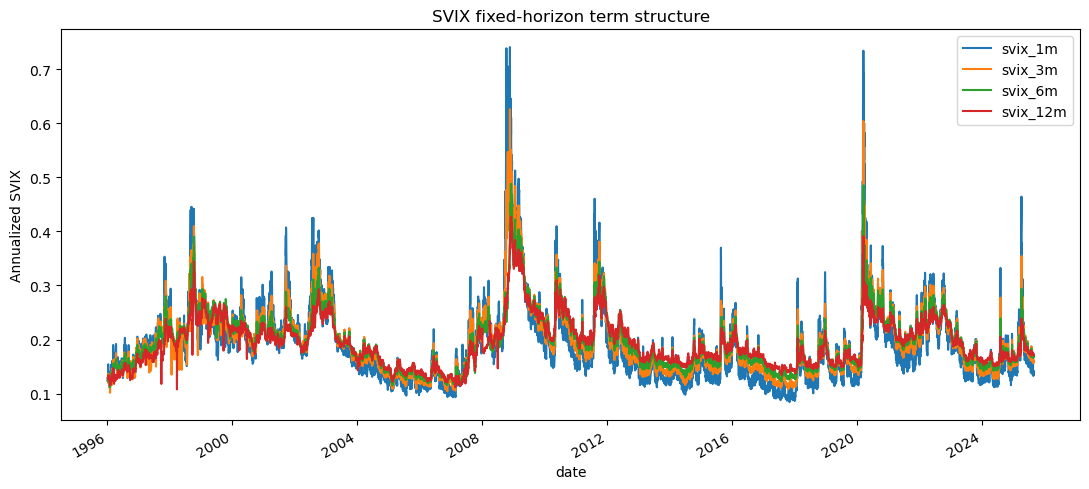

In [5]:
svix_plot = svix.copy()
svix_plot["date"] = pd.to_datetime(svix_plot["date"])

ax = svix_plot.set_index("date")[["svix_1m", "svix_3m", "svix_6m", "svix_12m"]].plot(
    figsize=(11, 5)
)
ax.set_ylabel("Annualized SVIX")
ax.set_title("SVIX fixed-horizon term structure")
plt.tight_layout()
plt.show()

## 4. Summary statistics

The summary-statistics output gives a compact view of the level and dispersion of SVIX across horizons before we move to the forecasting regressions.

In [6]:
pd.read_csv(OUTPUT_DIR / "svix_summary_stats.csv")

,sample,measure,horizon,mean,std,p1,p5,p25,p50,p75,p95,p99,min,max,n,start,end
0,full,svix,1m,18.939869,7.451450,9.508747,10.933994,13.723389,17.457892,22.057143,32.107138,46.981953,8.426730,74.101421,7453,1996-01-04,2025-08-29
1,full,svix,3m,19.497496,6.233002,11.314612,12.248337,14.822401,18.391483,22.643905,30.187645,41.637362,10.140201,62.609334,7453,1996-01-04,2025-08-29
2,full,svix,6m,19.615055,5.182844,12.159379,13.166232,15.580854,18.797754,22.576616,28.506989,36.867679,11.195179,48.785500,7453,1996-01-04,2025-08-29
3,full,svix,12m,19.343809,4.426015,12.311148,13.442178,16.161880,18.663121,21.874279,26.824765,34.423053,10.774853,42.760796,7453,1996-01-04,2025-08-29
4,full,svix2,1m,4.142353,4.185203,0.904163,1.195522,1.883314,3.047780,4.865176,10.308687,22.073130,0.710098,54.910207,7453,1996-01-04,2025-08-29
5,full,svix2,3m,4.189975,3.174105,1.280205,1.500218,2.197036,3.382467,5.127465,9.112939,17.336699,1.028237,39.199287,7453,1996-01-04,2025-08-29
6,full,svix2,6m,4.116087,2.399568,1.478505,1.733497,2.427630,3.533556,5.097036,8.126484,13.592272,1.253320,23.800250,7453,1996-01-04,2025-08-29
7,full,svix2,12m,3.937699,1.947007,1.515644,1.806922,2.612064,3.483121,4.784841,7.195680,11.849466,1.160975,18.284857,7453,1996-01-04,2025-08-29
8,martin2017,svix,1m,20.846584,7.991963,10.105641,11.148523,15.510950,19.605117,23.803033,35.831774,51.184457,9.317555,74.101421,4038,1996-01-04,2012-01-31
9,martin2017,svix,3m,21.024093,6.793040,11.139976,12.197461,16.248851,20.322821,24.174730,33.343675,45.693709,10.140201,62.609334,4038,1996-01-04,2012-01-31


Across the full sample, average annualized SVIX is close to 19–20% across maturities. Crisis peaks are much larger at the front end of the curve, which is consistent with near-term option prices reacting most strongly when perceived market risk rises suddenly.

## 5. Martin (2025) Table 1 replication

The central forecasting regression relates future S&P 500 excess returns to contemporaneous SVIX. The project reproduces the paper's original sample and uses horizon-specific Newey–West corrections for overlapping returns.

In [7]:
pd.read_csv(OUTPUT_DIR / "table1_replication.csv")

,sample,horizon,start,end_requested,last_usable_date,nobs,alpha,alpha_se_nw,alpha_t_nw,beta,beta_se_nw,beta_t_nw,r2,nw_lags
0,January 1996-December 2022,1m,1996-01-01,2022-12-31,2022-12-30,6785,0.018354,0.040955,0.448158,1.425292,1.018695,1.399135,0.011296,21
1,January 1996-December 2022,3m,1996-01-01,2022-12-31,2022-12-30,6786,0.014936,0.050480,0.295876,1.382435,1.258140,1.098793,0.021126,65
2,January 1996-December 2022,6m,1996-01-01,2022-12-31,2022-12-30,6786,-0.027246,0.036784,-0.740708,2.431783,0.788294,3.084869,0.070397,130
3,January 1996-December 2022,12m,1996-01-01,2022-12-31,2022-12-30,6786,-0.003759,0.043279,-0.086857,2.025703,0.797858,2.538927,0.056590,260
4,February 2012-December 2022,1m,2012-02-01,2022-12-31,2022-12-30,2748,-0.016296,0.035261,-0.462159,4.263675,0.801067,5.322493,0.078493,21
5,February 2012-December 2022,3m,2012-02-01,2022-12-31,2022-12-30,2748,-0.009326,0.041310,-0.225766,3.594210,0.990320,3.629344,0.124769,65
6,February 2012-December 2022,6m,2012-02-01,2022-12-31,2022-12-30,2748,0.011317,0.052057,0.217407,2.967200,1.614807,1.837495,0.115081,130
7,February 2012-December 2022,12m,2012-02-01,2022-12-31,2022-12-30,2748,0.004194,0.067453,0.062178,3.292227,2.287289,1.439358,0.124059,260


In [8]:
pd.read_csv(OUTPUT_DIR / "table1_published_comparison.csv")

,horizon,alpha_rep_1996_2022,alpha_pub_1996_2022,alpha_abs_diff_1996_2022,alpha_se_rep_1996_2022,alpha_se_pub_1996_2022,alpha_se_abs_diff_1996_2022,beta_rep_1996_2022,beta_pub_1996_2022,beta_abs_diff_1996_2022,beta_se_rep_1996_2022,beta_se_pub_1996_2022,beta_se_abs_diff_1996_2022,r2_rep_1996_2022,r2_pub_1996_2022,r2_abs_diff_1996_2022,alpha_rep_2012_2022,alpha_pub_2012_2022,alpha_abs_diff_2012_2022,alpha_se_rep_2012_2022,alpha_se_pub_2012_2022,alpha_se_abs_diff_2012_2022,beta_rep_2012_2022,beta_pub_2012_2022,beta_abs_diff_2012_2022,beta_se_rep_2012_2022,beta_se_pub_2012_2022,beta_se_abs_diff_2012_2022,r2_rep_2012_2022,r2_pub_2012_2022,r2_abs_diff_2012_2022
0,1m,0.018354,0.014,0.004354,0.040955,0.041,0.000045,1.425292,1.569,0.143708,1.018695,1.024,0.005305,0.011296,0.01302,0.001724,-0.016296,-0.015,0.001296,0.035261,0.035,0.000261,4.263675,4.280,0.016325,0.801067,0.822,0.020933,0.078493,0.07809,0.000403
1,3m,0.014936,0.015,0.000064,0.050480,0.051,0.000520,1.382435,1.439,0.056565,1.258140,1.269,0.010860,0.021126,0.02201,0.000884,-0.009326,-0.008,0.001326,0.041310,0.041,0.000310,3.594210,3.620,0.025790,0.990320,0.997,0.006680,0.124769,0.12334,0.001429
2,6m,-0.027246,-0.025,0.002246,0.036784,0.037,0.000216,2.431783,2.418,0.013783,0.788294,0.806,0.017706,0.070397,0.06840,0.001997,0.011317,0.011,0.000317,0.052057,0.053,0.000943,2.967200,3.007,0.039800,1.614807,1.633,0.018193,0.115081,0.11454,0.000541
3,12m,-0.003759,0.003,0.006759,0.043279,0.043,0.000279,2.025703,1.858,0.167703,0.797858,0.824,0.026142,0.056590,0.04727,0.009320,0.004194,0.008,0.003806,0.067453,0.070,0.002547,3.292227,3.188,0.104227,2.287289,2.368,0.080711,0.124059,0.11316,0.010899


The replication is close to the published results across horizons. The 6-month coefficient is especially close to Martin's published estimate, and the project's replication-tolerance tests confirm that the results fall within documented numerical tolerances.

In [9]:
pd.read_csv(OUTPUT_DIR / "replication_tolerance_report.csv")

,horizon,sample,metric,absolute_difference,tolerance,tolerance_utilization,within_tolerance
0,1m,1996_2022,alpha,0.004354,0.010,0.435420,True
1,1m,1996_2022,alpha_se,0.000045,0.010,0.004520,True
2,1m,1996_2022,beta,0.143708,0.200,0.718538,True
3,1m,1996_2022,beta_se,0.005305,0.100,0.053047,True
4,1m,1996_2022,r2,0.001724,0.012,0.143700,True
5,1m,2012_2022,alpha,0.001296,0.010,0.129614,True
6,1m,2012_2022,alpha_se,0.000261,0.010,0.026090,True
7,1m,2012_2022,beta,0.016325,0.200,0.081624,True
8,1m,2012_2022,beta_se,0.020933,0.100,0.209326,True
9,1m,2012_2022,r2,0.000403,0.012,0.033598,True


## 6. Updated results through 2025

The same forecasting specification is recomputed using all available data. Because realized returns must be observed after the forecast date, the latest usable date depends on the horizon.

In [10]:
pd.read_csv(OUTPUT_DIR / "table1_updated.csv")

,sample,horizon,start,end_requested,last_usable_date,nobs,alpha,alpha_se_nw,alpha_t_nw,beta,beta_se_nw,beta_t_nw,r2,nw_lags
0,January 1996-latest usable,1m,1996-01-01,2025-08-29,2025-08-29,7452,0.026955,0.039155,0.688417,1.458270,1.008069,1.446598,0.011439,21
1,January 1996-latest usable,3m,1996-01-01,2025-08-29,2025-08-29,7453,0.026499,0.048228,0.549454,1.351799,1.238365,1.091600,0.019494,65
2,January 1996-latest usable,6m,1996-01-01,2025-08-29,2025-07-03,7413,-0.011206,0.034223,-0.327436,2.285931,0.774426,2.951775,0.061139,130
3,January 1996-latest usable,12m,1996-01-01,2025-08-29,2025-01-03,7290,0.009616,0.040252,0.238890,1.867740,0.783815,2.382882,0.047827,260


In [11]:
pd.read_csv(OUTPUT_DIR / "table1_post2022.csv")

,sample,horizon,start,end_requested,last_usable_date,nobs,alpha,alpha_se_nw,alpha_t_nw,beta,beta_se_nw,beta_t_nw,r2,nw_lags,hac_lag_share,independent_periods,inference_reliable
0,January 2023-latest usable,1m,2023-01-01,2025-08-29,2025-08-29,667,-0.068611,0.082400,-0.832658,8.655237,2.432597,3.558024,0.111499,21,0.031484,32.37,True
1,January 2023-latest usable,3m,2023-01-01,2025-08-29,2025-08-29,667,-0.118621,0.100704,-1.177918,9.902567,2.105976,4.702127,0.227523,65,0.097451,10.79,True
2,January 2023-latest usable,6m,2023-01-01,2025-08-29,2025-07-03,627,-0.021701,0.115866,-0.187292,6.150570,3.259414,1.887017,0.146848,130,0.207337,5.08,True
3,January 2023-latest usable,12m,2023-01-01,2025-08-29,2025-01-03,504,-0.025512,0.069294,-0.368168,6.221251,1.834097,3.391997,0.202278,260,0.515873,2.04,False


The post-2022 estimates remain positive at all four horizons and are particularly strong at 1 and 3 months. The 12-month result is economically large, but it should be interpreted cautiously because the short updated sample contains only about two independent 12-month periods after accounting for overlapping returns.

## 7. Martin (2025) Figures 1 and 2 — power utility

The project also replicates the paper's power-utility equity-premium figures for risk aversion \(\gamma = 1,2,3\), then extends the same calculations through the latest available data.

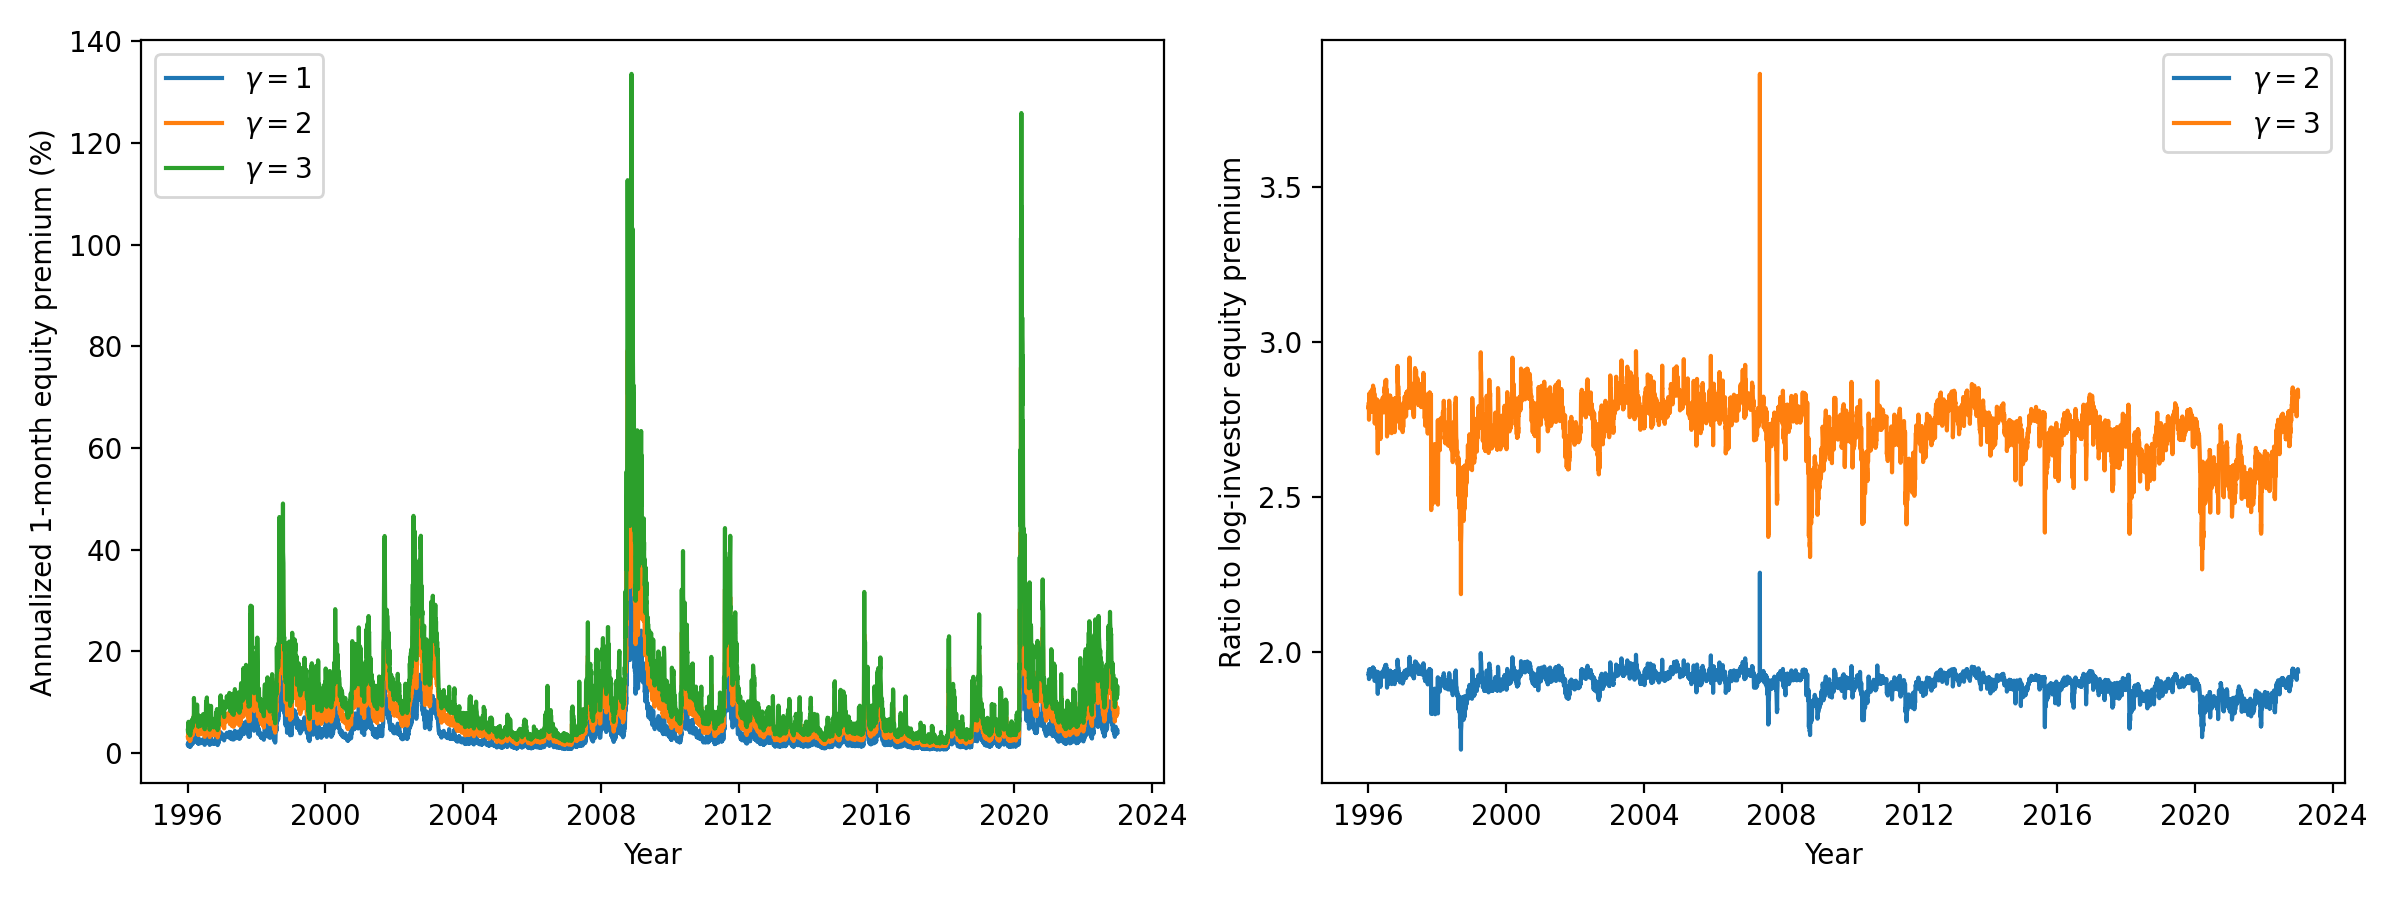

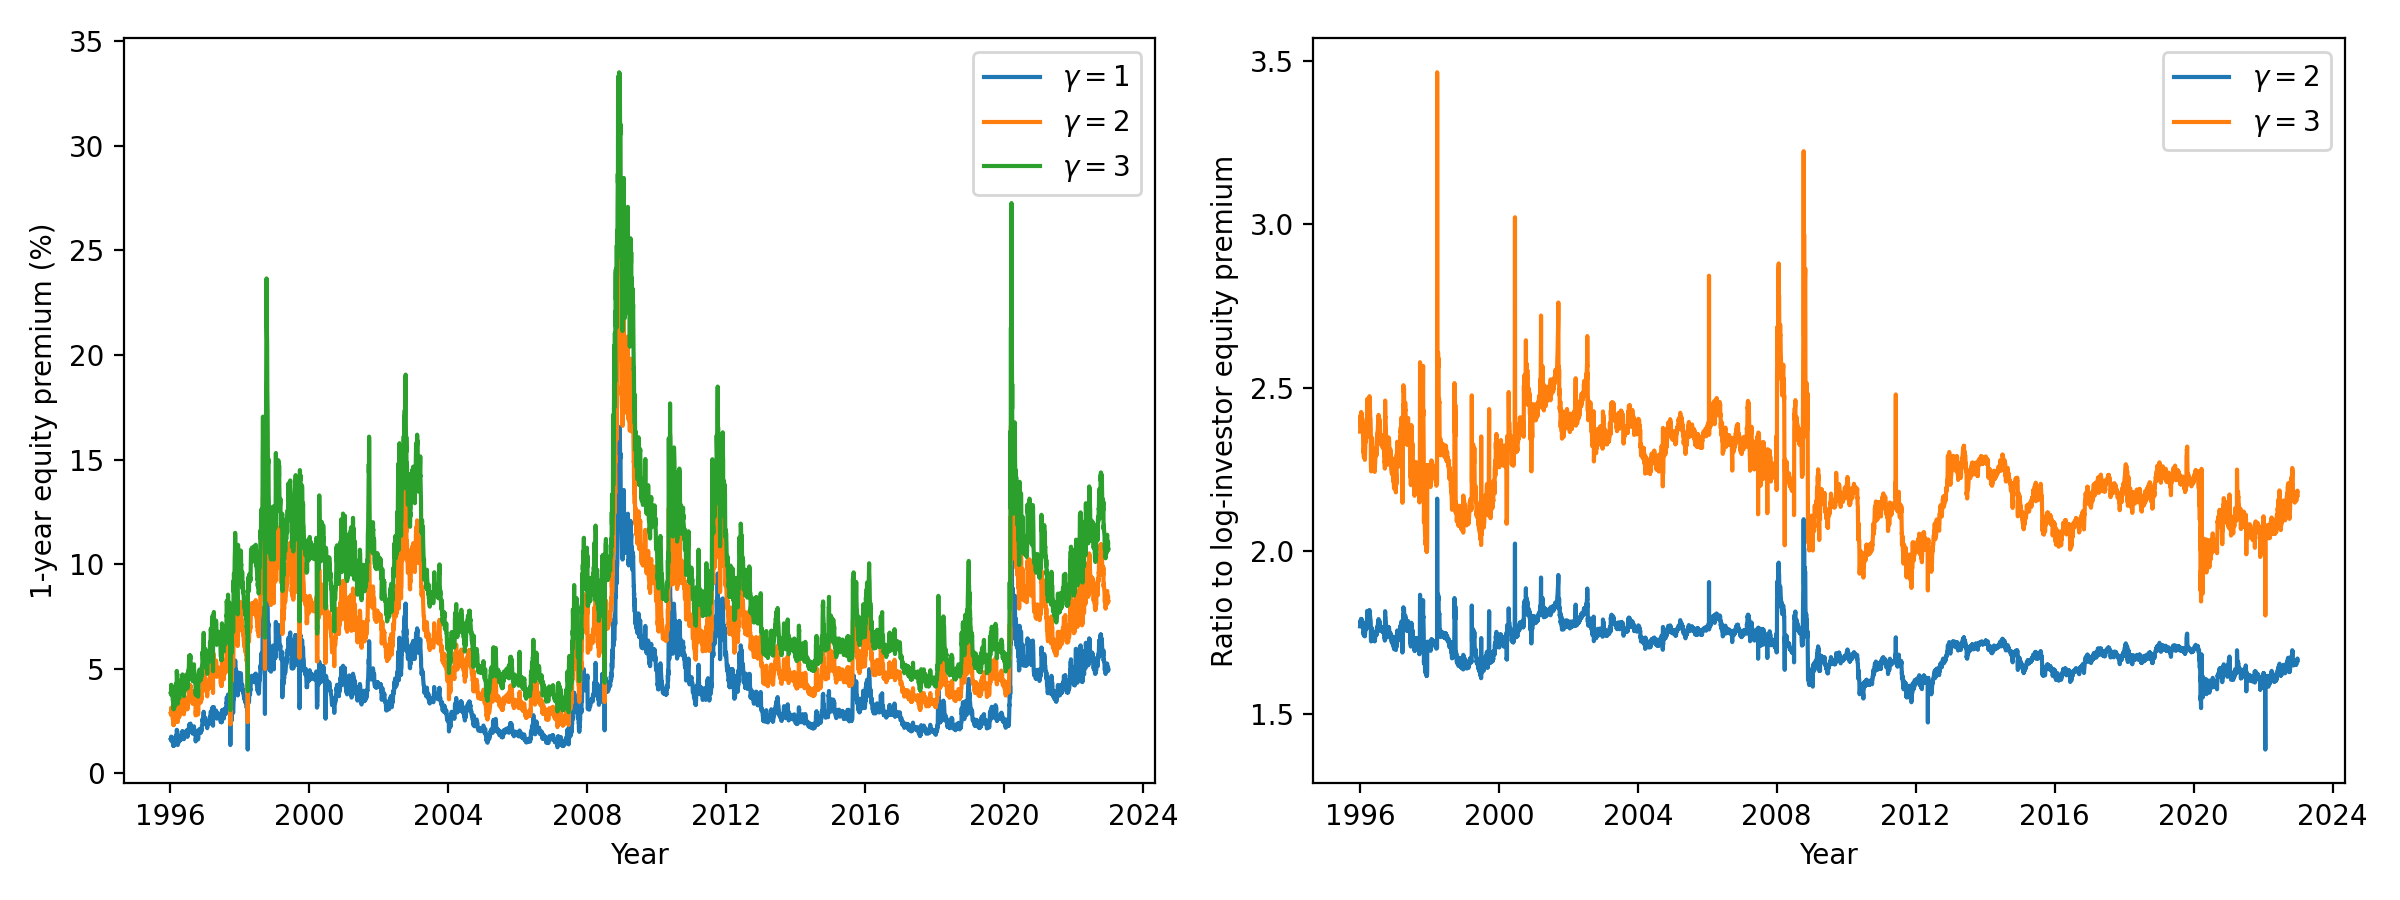

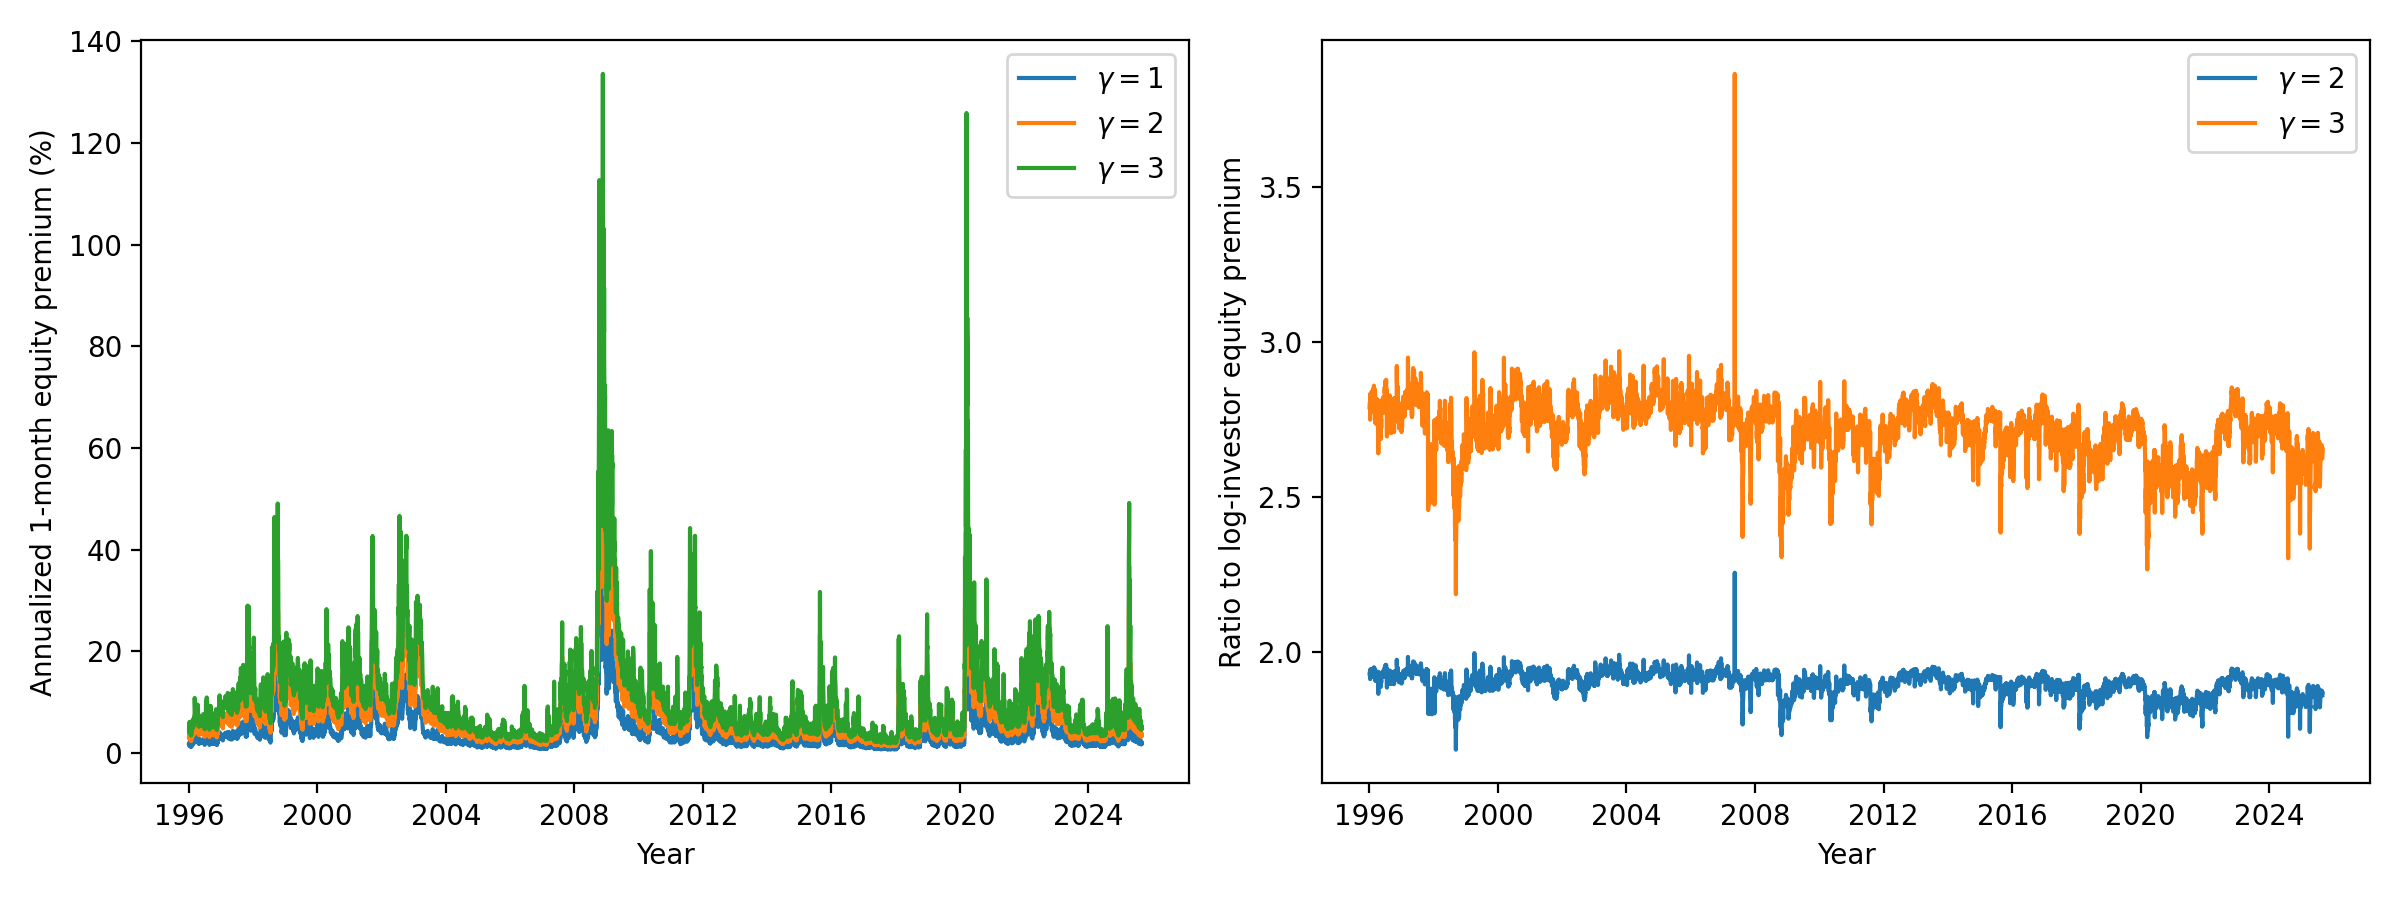

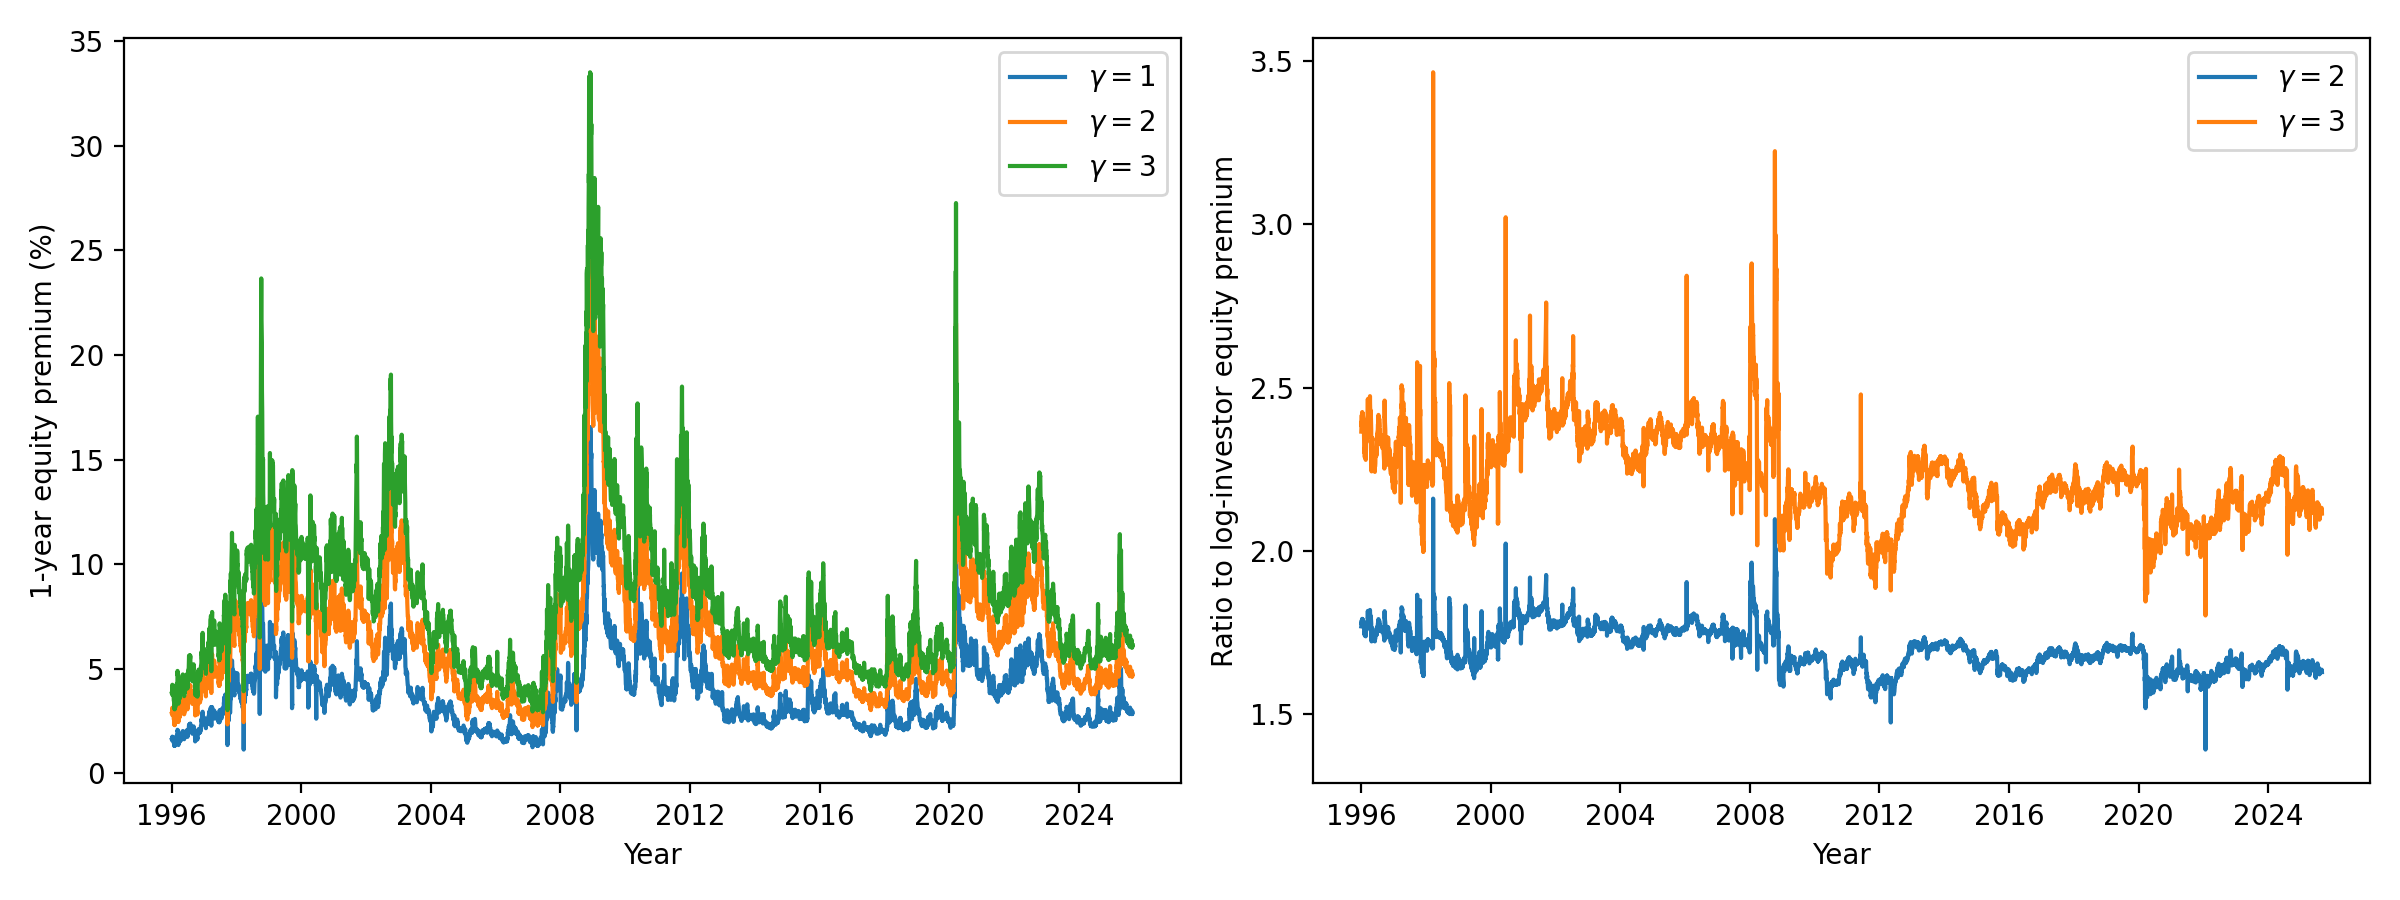

In [12]:
display(Image(filename=str(OUTPUT_DIR / "figure1_power_utility_replication.png")))
display(Image(filename=str(OUTPUT_DIR / "figure2_power_utility_replication.png")))
display(Image(filename=str(OUTPUT_DIR / "figure1_power_utility_updated.png")))
display(Image(filename=str(OUTPUT_DIR / "figure2_power_utility_updated.png")))

The updated figures preserve the same economic interpretation as the replication sample: higher option-implied risk is associated with a larger required equity premium, and the effect becomes more pronounced for more risk-averse investors during periods of market stress.

## 8. Forecast-horizon comparison

In [13]:
pd.read_csv(OUTPUT_DIR / "horizon_comparison.csv")

,horizon,nobs,in_sample_r2,rmse,mae,bias,correlation,oos_nobs,oos_r2,oos_rmse,oos_mae
0,1m,7452,0.011439,0.567284,0.414513,-2.669779e-17,0.106953,6192,-0.010271,0.580087,0.417707
1,3m,7453,0.019494,0.304284,0.226732,3.050767e-17,0.139621,6193,-0.006348,0.311281,0.235077
2,6m,7413,0.061139,0.215384,0.163851,-3.067229e-17,0.247262,6153,0.062686,0.217584,0.168162
3,12m,7290,0.047827,0.163660,0.123212,3.898726e-17,0.218694,6030,0.027847,0.163125,0.125324


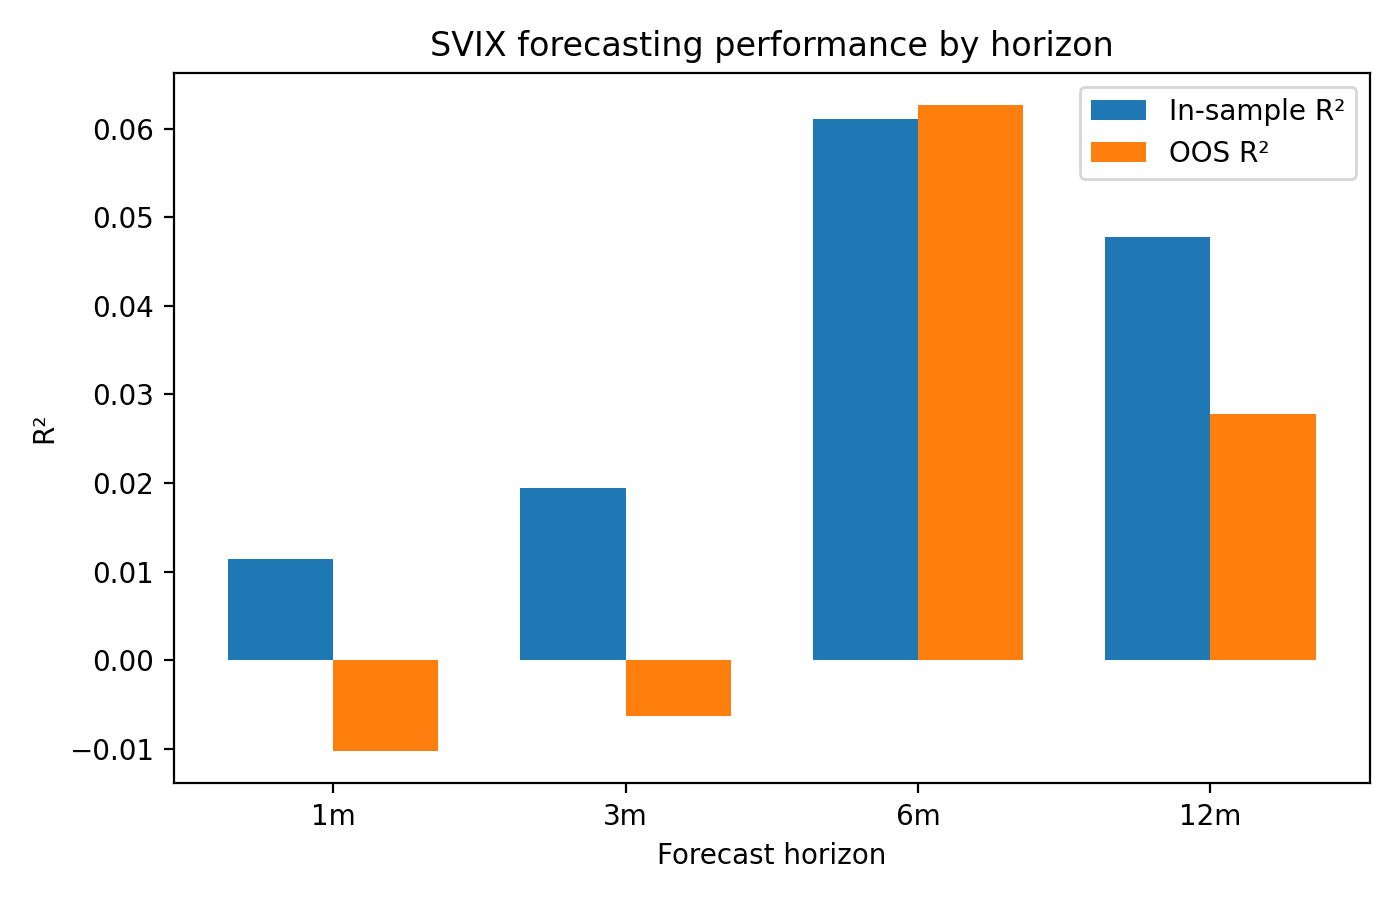

In [14]:
display(Image(filename=str(OUTPUT_DIR / "horizon_comparison.png")))

The 6-month horizon has the strongest out-of-sample performance in the project. The 12-month horizon also remains positive out of sample, while the 1- and 3-month horizons have negative out-of-sample \(R^2\).

## 9. Time variation, regimes, and robustness

A constant full-sample coefficient can hide substantial changes through time. The remaining extensions examine rolling estimates, market regimes, crisis sensitivity, and the forward-price convention.

In [15]:
pd.read_csv(OUTPUT_DIR / "rolling_predictive_power.csv").head()

,date,horizon,window_obs,alpha,beta,beta_t_nw,r2
0,2001-01-04,1m,1260,-0.047504,3.867190,1.487372,0.026363
1,2001-02-05,1m,1260,-0.100324,4.526556,1.746057,0.034557
2,2001-03-07,1m,1260,-0.109454,4.270548,1.597080,0.027732
3,2001-04-05,1m,1260,-0.127753,4.816135,1.838861,0.034811
4,2001-05-07,1m,1260,-0.151345,5.320849,2.006050,0.041602


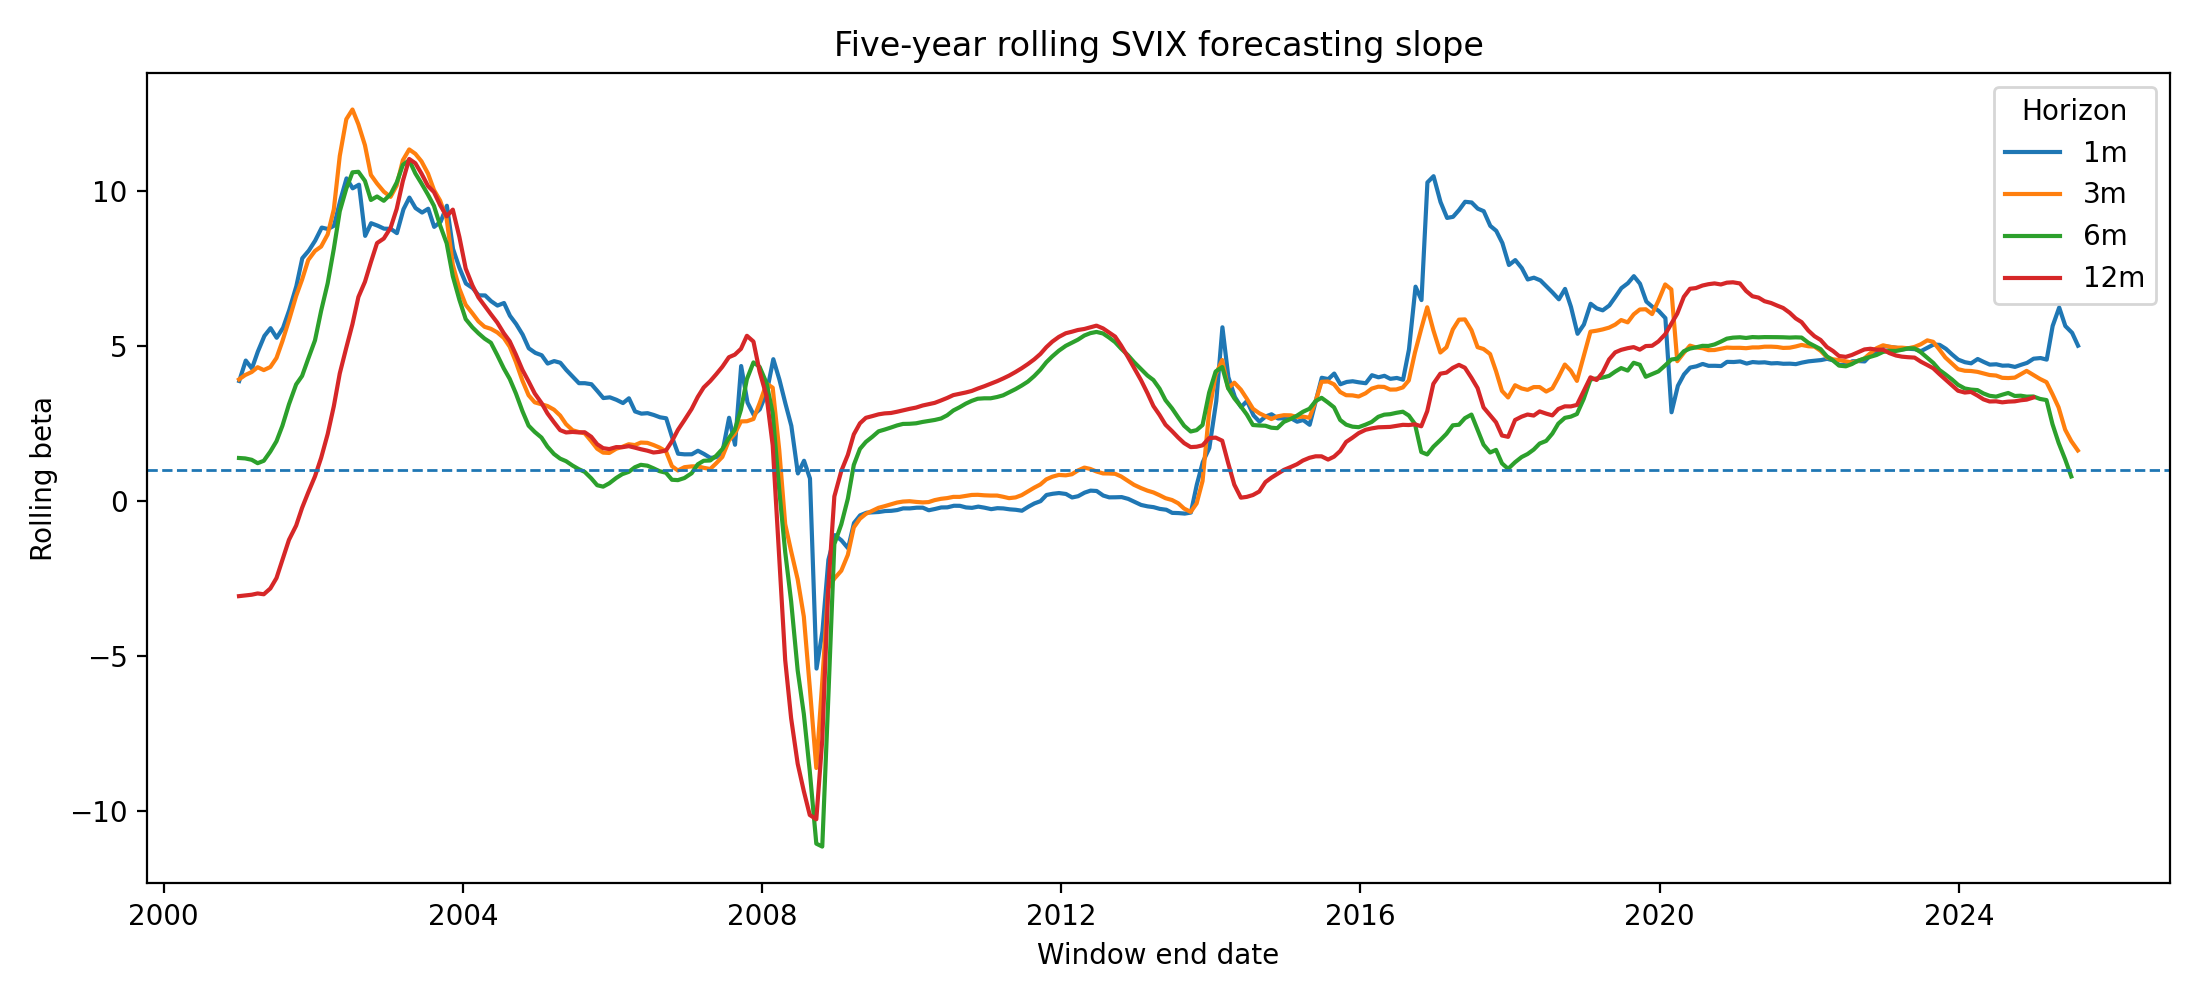

In [16]:
display(Image(filename=str(OUTPUT_DIR / "rolling_predictive_beta.png")))

The rolling estimates show that the forecasting coefficient is not stable through time. Large changes occur around major market episodes, so the full-sample slope should be interpreted as an average across very different environments.

In [17]:
pd.read_csv(OUTPUT_DIR / "regime_analysis.csv").head(24)

,horizon,regime_type,regime,nobs,alpha,beta,beta_t_nw,r2
0,1m,market_direction,falling,2600,0.057277,1.212730,0.978902,0.010106
1,1m,market_direction,rising,4832,0.002442,1.878655,1.436965,0.009203
2,1m,vol_regime,high_vol,3235,0.006960,1.617839,1.306922,0.015094
3,1m,vol_regime,low_vol,3946,0.042558,0.645715,0.290955,0.000246
4,1m,svix_regime,high_svix,3185,0.007761,1.651668,1.285304,0.015012
5,1m,svix_regime,low_svix,4016,0.096799,-1.968020,-0.643129,0.001407
6,3m,market_direction,falling,2601,0.041610,1.122950,0.780740,0.016148
7,3m,market_direction,rising,4832,0.011616,1.713655,1.419790,0.020707
8,3m,vol_regime,high_vol,3236,-0.000247,1.662566,0.968492,0.028308
9,3m,vol_regime,low_vol,3946,0.057163,0.163814,0.096536,0.000056


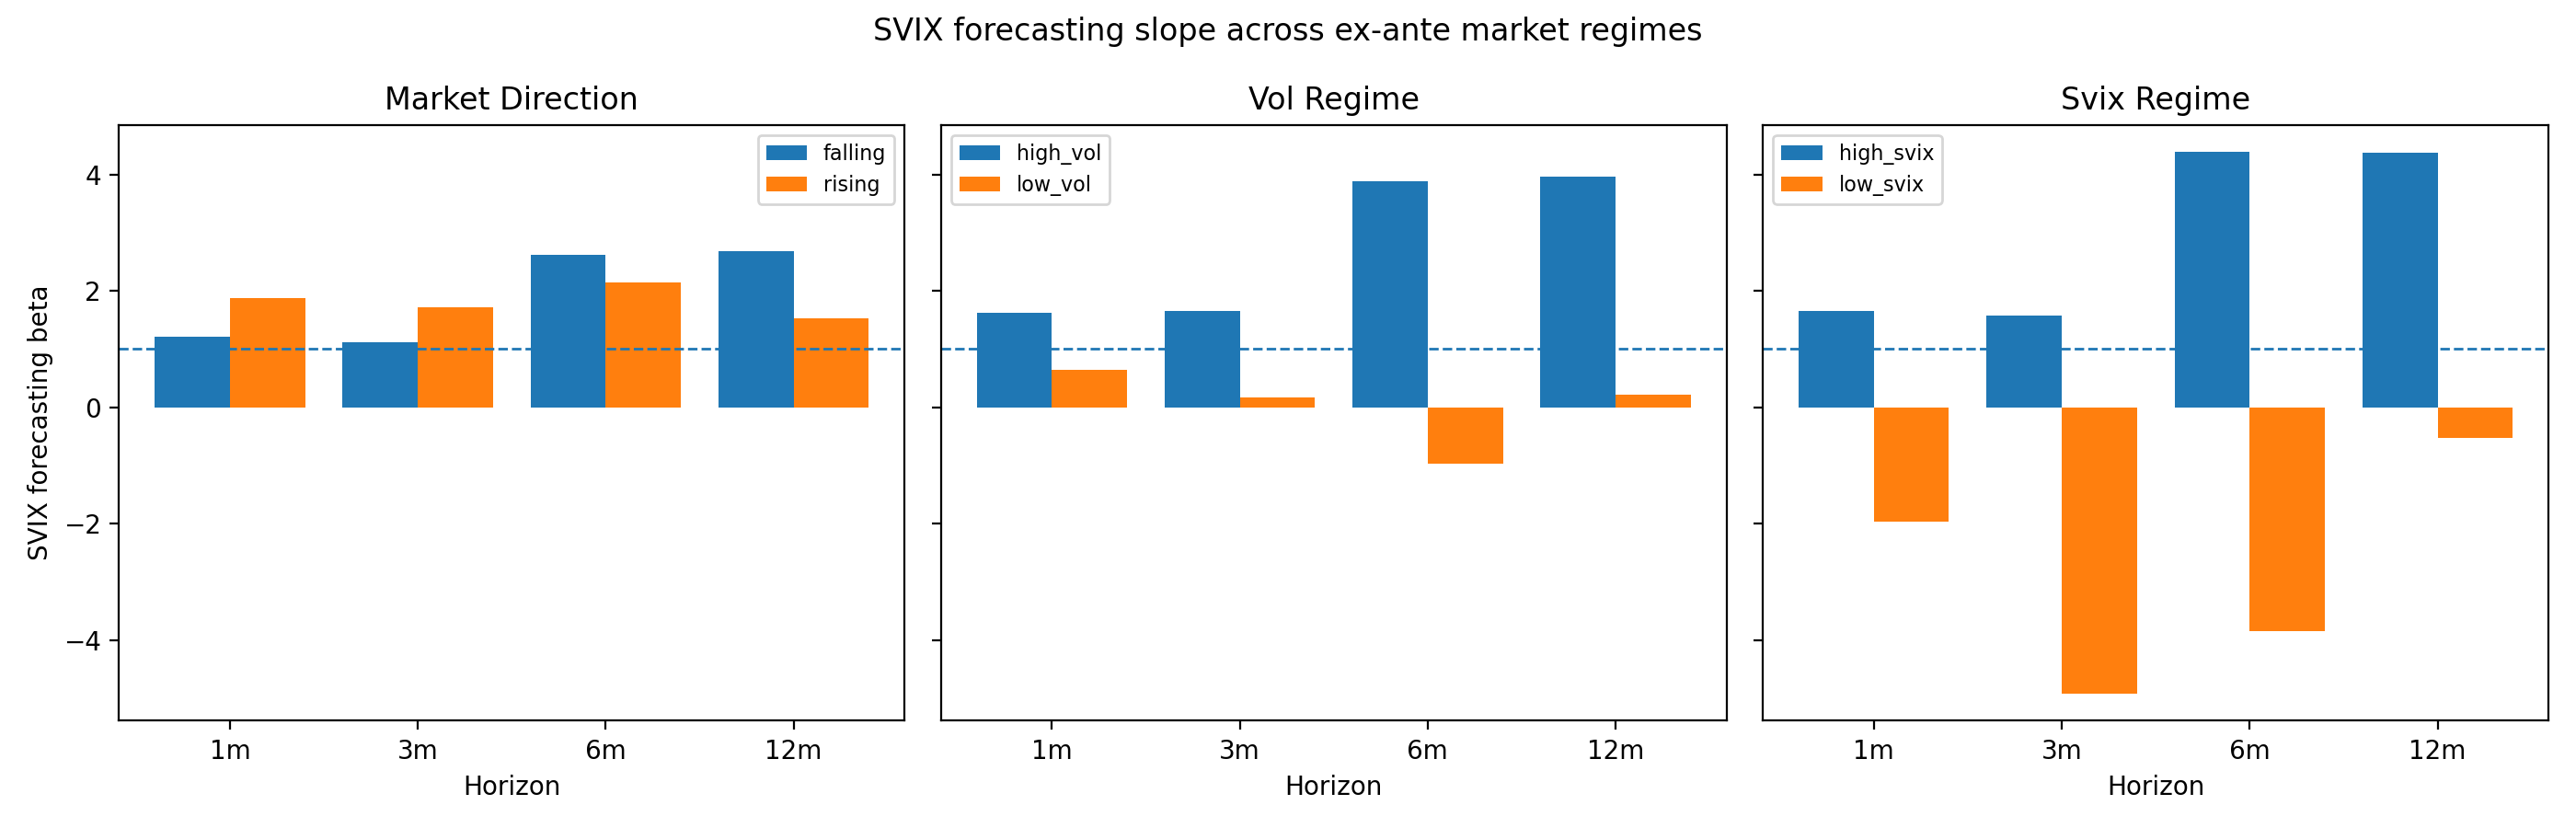

In [18]:
display(Image(filename=str(OUTPUT_DIR / "regime_beta_comparison.png")))

The regime analysis shows the strongest state dependence at the 6- and 12-month horizons. Predictive power is much stronger when realized volatility or SVIX is high and is weak in several calm-market specifications.

In [19]:
pd.read_csv(OUTPUT_DIR / "crisis_window_analysis.csv")

,horizon,beta_full,beta_ex_crisis,beta_change,beta_published,abs_gap_full,abs_gap_ex_crisis,r2_full,r2_ex_crisis,nobs_full,nobs_ex_crisis,crisis_obs_dropped
0,1m,1.425292,3.388403,1.963111,1.569,0.143708,1.819403,0.011296,0.035864,6785,6660,125
1,3m,1.382435,3.024794,1.642359,1.439,0.056565,1.585794,0.021126,0.061606,6786,6661,125
2,6m,2.431783,2.635108,0.203325,2.418,0.013783,0.217108,0.070397,0.060253,6786,6661,125
3,12m,2.025703,1.661664,-0.364038,1.858,0.167703,0.196336,0.056590,0.027284,6786,6661,125


In [20]:
pd.read_csv(OUTPUT_DIR / "crisis_leave_one_year_out.csv").head(20)

,horizon,excluded_year,beta,beta_full,beta_change,nobs
0,1m,1996,1.476542,1.425292,0.051250,6533
1,1m,1997,1.417131,1.425292,-0.008161,6534
2,1m,1998,1.287717,1.425292,-0.137575,6535
3,1m,1999,1.384332,1.425292,-0.040960,6533
4,1m,2000,1.421675,1.425292,-0.003618,6533
5,1m,2001,1.293446,1.425292,-0.131846,6537
6,1m,2002,1.382543,1.425292,-0.042749,6535
7,1m,2003,1.434733,1.425292,0.009441,6535
8,1m,2004,1.412156,1.425292,-0.013137,6535
9,1m,2005,1.435959,1.425292,0.010667,6533


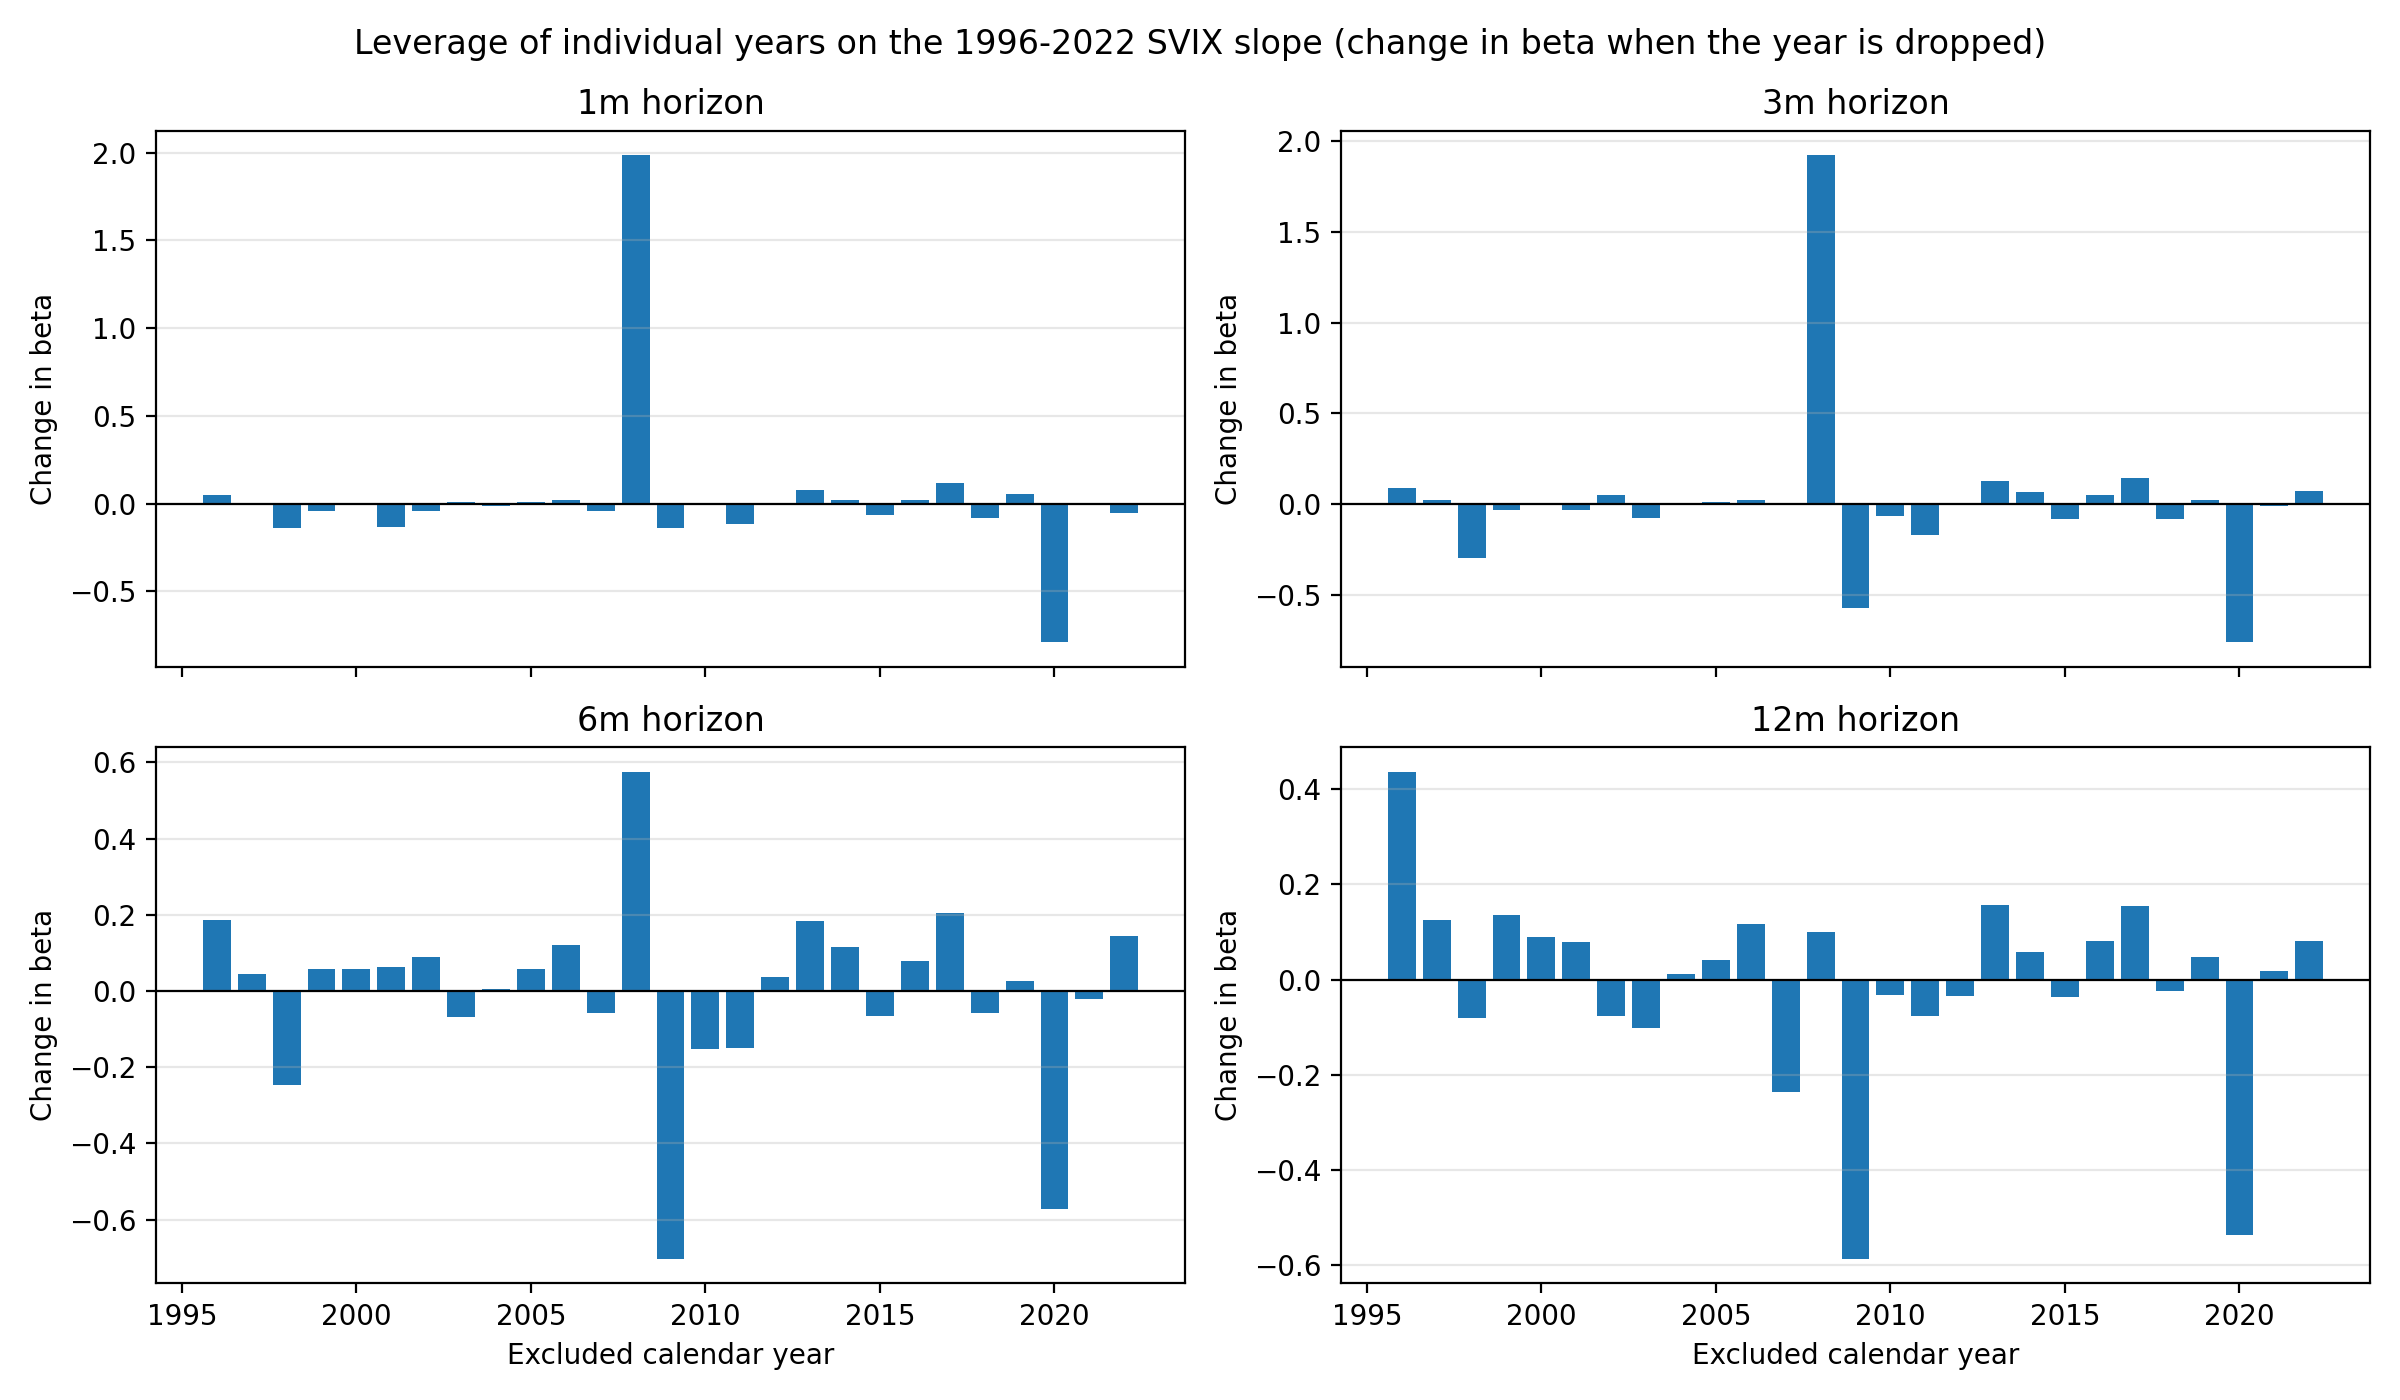

In [21]:
display(Image(filename=str(OUTPUT_DIR / "crisis_leave_one_year_out.png")))

The crisis checks show that the positive relationship is not simply created by the Global Financial Crisis. Removing the main 2008–2009 crisis window actually increases the short-horizon slopes, although individual years such as 2008, 2009, and 2020 have substantial leverage.

In [22]:
pd.read_csv(OUTPUT_DIR / "forward_price_discrepancy.csv")

,dte_bucket,n,mean_rel_diff_bp,median_abs_rel_diff_bp,p95_abs_rel_diff_bp
0,"[0, 45)",48035,-0.152094,5.053569,18.570355
1,"[45, 90)",21382,0.286777,6.681674,27.383803
2,"[90, 180)",23397,-0.145110,8.419977,32.349762
3,"[180, 270)",14985,1.549413,10.886116,44.765326
4,"[270, 400)",18641,2.700121,14.636430,54.321099
5,"[400, 550)",7893,7.315931,19.594339,80.012554


In [23]:
pd.read_csv(OUTPUT_DIR / "forward_robustness_table1.csv")

,horizon,beta_parity_forward,beta_om_forward,beta_change,beta_published,abs_gap_parity,abs_gap_om,r2_parity_forward,r2_om_forward,nobs_parity,nobs_om
0,1m,1.425295,1.425295,0.000000,1.569,0.143705,0.143705,0.011296,0.011296,6785,6785
1,3m,1.382438,1.382435,-0.000003,1.439,0.056562,0.056565,0.021126,0.021126,6786,6786
2,6m,2.431782,2.431793,0.000012,2.418,0.013782,0.013793,0.070397,0.070398,6786,6786
3,12m,2.025699,2.025693,-0.000006,1.858,0.167699,0.167693,0.056590,0.056589,6786,6786


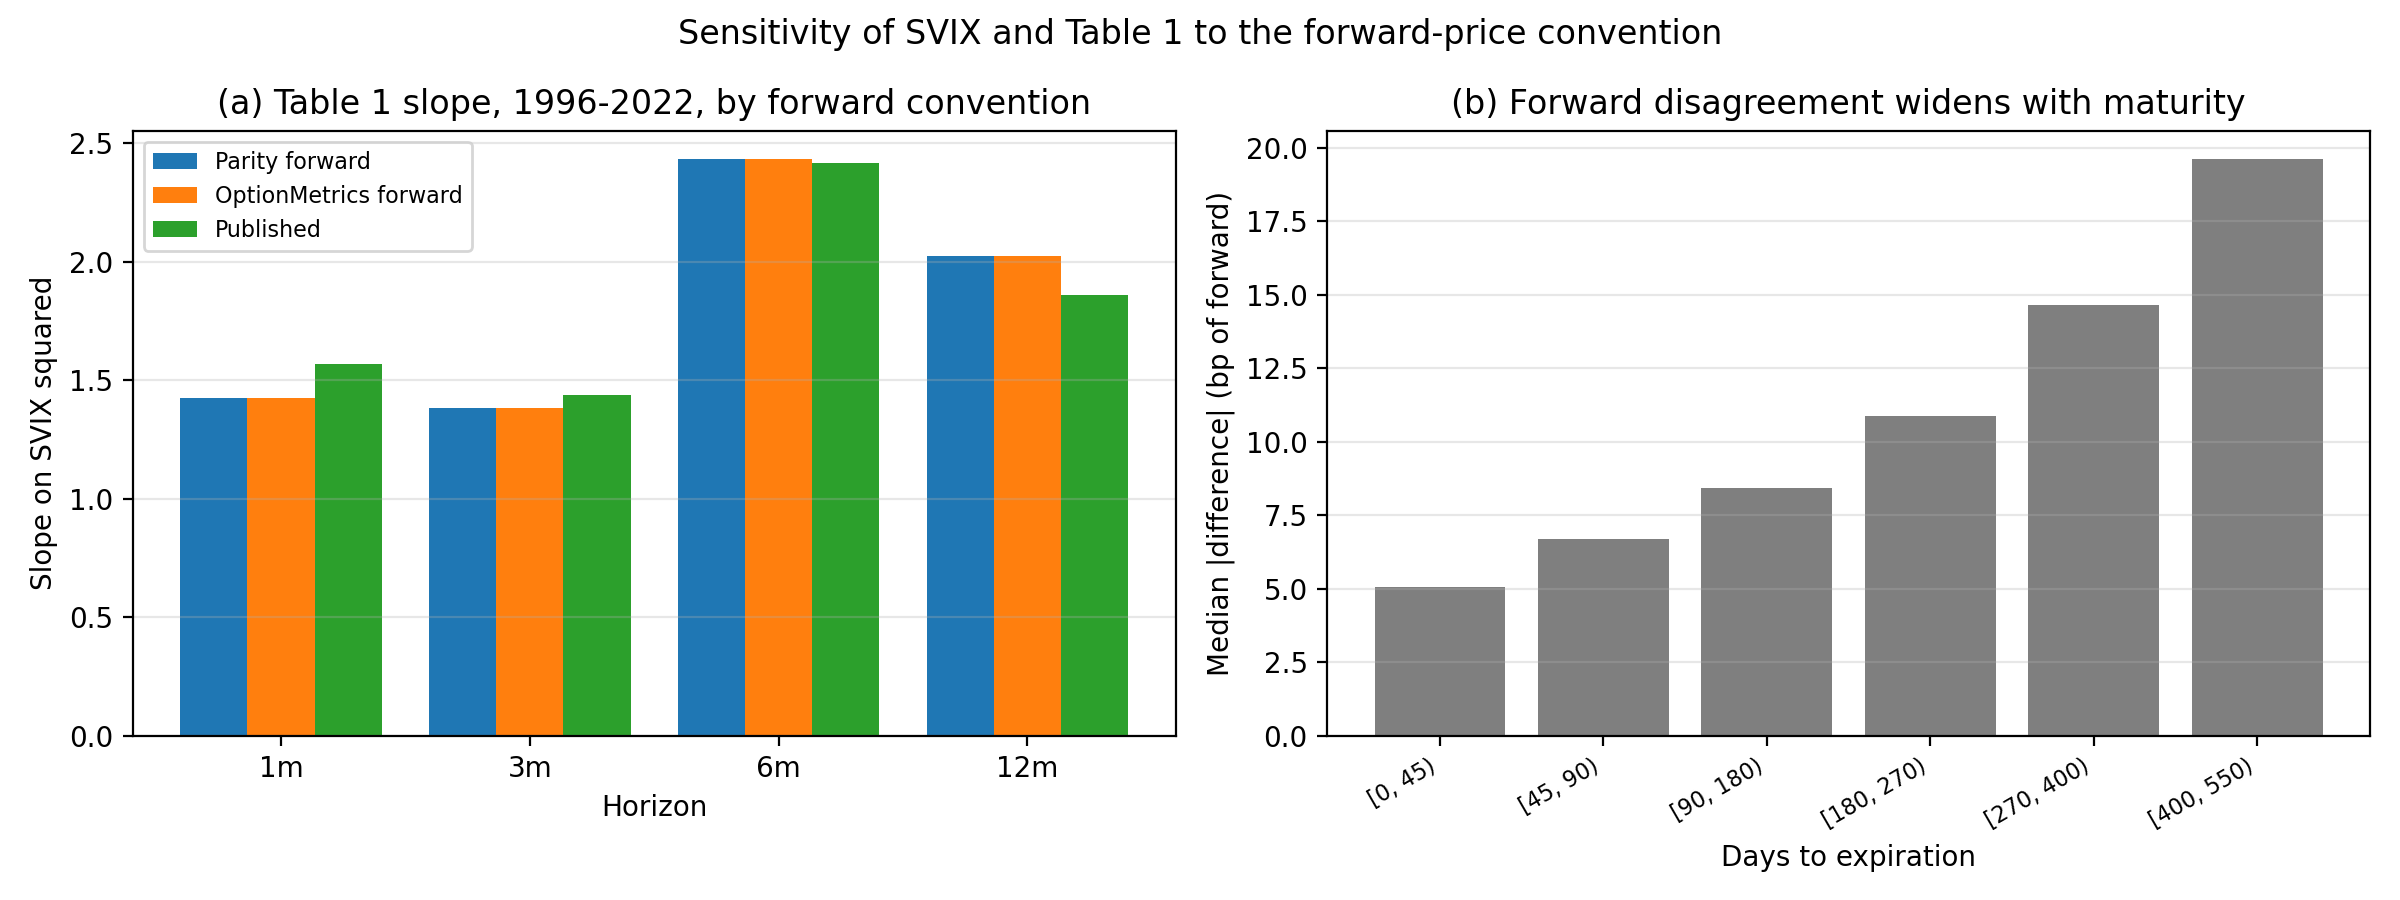

In [24]:
display(Image(filename=str(OUTPUT_DIR / "forward_robustness.png")))

Although the alternative forward prices differ modestly from the baseline construction, the resulting Table 1 coefficients are essentially unchanged. The main replication results are therefore not an artifact of the forward-price convention.

## 10. Main takeaways

1. **The replication works.** The original-sample forecasting regressions and power-utility figures closely match Martin's published results within documented tolerances.
2. **The relationship persists after 2022.** Updated estimates remain positive, although long-horizon inference is limited by the short amount of non-overlapping post-2022 data.
3. **Forecasting performance depends on horizon.** The 6-month horizon produces the strongest out-of-sample performance, while the shortest horizons are weaker out of sample.
4. **The relationship is state dependent.** SVIX is substantially more informative in high-volatility and high-SVIX environments than in calm markets.
5. **The main findings are robust.** Crisis-window tests and an alternative forward-price convention do not overturn the central results.

This notebook is intentionally a tour rather than the implementation itself. The reusable research logic remains in the project modules under `src/`, where it can be tested, modified, and run end-to-end with PyDoit.